In [ ]:
!pip install google-generativeai langchain langchain-core graphviz

In [2]:
import google.generativeai as genai
from getpass import getpass
from langchain.prompts import ChatPromptTemplate
from langchain.schema.output_parser import StrOutputParser
from langchain_core.runnables import RunnableSequence, RunnableLambda, RunnableParallel
from graphviz import Digraph

In [3]:
api_key = getpass("🔑 Enter your Gemini API key: ")
genai.configure(api_key=api_key)

# Create a custom LLM class that wraps Gemini for LangChain compatibility
from langchain_core.language_models.llms import LLM
from typing import Optional, List, Mapping, Any

class GeminiLLM(LLM):
    model_name: str = "gemini-2.5-flash"
    
    @property
    def _llm_type(self) -> str:
        return "gemini"
    
    def _call(self, prompt: str, stop: Optional[List[str]] = None, **kwargs) -> str:
        model = genai.GenerativeModel(self.model_name)
        response = model.generate_content(prompt)
        return response.text
    
    @property
    def _identifying_params(self) -> Mapping[str, Any]:
        return {"model_name": self.model_name}

model = GeminiLLM()

In [4]:
# Model & prompt
prompt = ChatPromptTemplate.from_template("Write a haiku about {topic}.")
parser = StrOutputParser()

# RunnableSequence
seq = prompt | model | parser

# Preprocessing lambda
preprocess = RunnableLambda(lambda x: {"topic": x["topic"].upper()})

# Full single sequence chain
single_chain = preprocess | (lambda x: seq.invoke(x))

# Parallel chains
branch1 = RunnableLambda(lambda x: seq.invoke(x))
branch2 = RunnableLambda(lambda x: seq.invoke(x))
parallel_chain = RunnableParallel({"branch1": branch1, "branch2": branch2})

In [5]:
# Modified function that only saves DOT file
def draw_sequence_graph_dot_only(chain, filename="sequence_graph"):
    dot = Digraph(comment="RunnableSequence Graph")

    nodes = []
    # Flatten the chain into nodes
    if isinstance(chain, RunnableSequence):
        if chain.first: nodes.append(("first", chain.first.__class__.__name__))
        for i, mid in enumerate(chain.middle):
            nodes.append((f"middle{i}", mid.__class__.__name__))
        if chain.last: nodes.append(("last", chain.last.__class__.__name__))
    elif isinstance(chain, RunnableLambda):
        nodes.append(("lambda", chain.__class__.__name__))

    # Add nodes
    for node_id, label in nodes:
        dot.node(node_id, label)

    # Add edges
    for i in range(len(nodes)-1):
        dot.edge(nodes[i][0], nodes[i+1][0])

    # Save the DOT source
    dot.save(filename + ".dot")
    print(f"DOT file saved to {filename}.dot")
    print("To view the graph, upload this file to: https://dreampuf.github.io/GraphvizOnline/")

    # Also print the DOT source
    print("\nDOT Source:")
    print(dot.source)

# Use the modified function
draw_sequence_graph_dot_only(single_chain, filename="single_sequence")

DOT file saved to single_sequence.dot
To view the graph, upload this file to: https://dreampuf.github.io/GraphvizOnline/

DOT Source:
// RunnableSequence Graph
digraph {
	first [label=RunnableLambda]
	last [label=RunnableLambda]
	first -> last
}



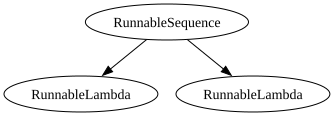

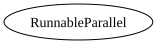

In [6]:
from graphviz import Digraph

def visualize_chain(chain, graph=None, parent=None, name="root"):
    if graph is None:
        graph = Digraph(comment="LangChain Graph")

    node_label = type(chain).__name__
    graph.node(name, node_label)

    if parent:
        graph.edge(parent, name)

    if isinstance(chain, RunnableSequence):
        # Add first
        if chain.first:
            visualize_chain(chain.first, graph, parent=name, name=name+"_first")
        # Add middle
        for i, mid in enumerate(chain.middle):
            visualize_chain(mid, graph, parent=name, name=f"{name}_mid{i}")
        # Add last
        if chain.last:
            visualize_chain(chain.last, graph, parent=name, name=name+"_last")

    elif isinstance(chain, RunnableParallel):
        # Access branches via steps__ (internal dict)
        branches = getattr(chain, "steps__", {})
        for branch_name, branch_runnable in branches.items():
            visualize_chain(branch_runnable, graph, parent=name, name=f"{name}_{branch_name}")

    return graph

# --- Generate and display graphs ---
graph1 = visualize_chain(single_chain)
graph2 = visualize_chain(parallel_chain)

display(graph1)
display(graph2)